In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import xgboost as xgb

In [2]:
df = pd.read_csv(r"D:\Data Analytics & Data Science\NetMax Technologies\heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(723)

In [5]:
df.drop_duplicates(inplace=True)

In [7]:
# renaming the columns for better understanding
df.rename(columns={"age": "Age", 
                   "sex": "Sex", 
                   "cp": "Chest_Pain_Type", 
                   "trestbps": "Resting_Blood_Pressure",
                   "chol": "Cholesterol",
                    "fbs": "Fasting_Blood_Sugar", 
                    "restecg": "Resting_ECG_Results", 
                    "thalach": "Maximum_Heart_Rate", 
                    "exang": "Exercise_Induced_Angina", 
                    "oldpeak": "ST_Depression_Oldpeak", 
                    "slope": "ST_Segment_Slope", 
                    "ca": "Number_of_Major_Vessels", 
                    "thal": "Thalassemia", 
                    "target": "Heart_Disease"}, inplace=True)

In [8]:
df.head()

,Age,Sex,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Resting_ECG_Results,Maximum_Heart_Rate,Exercise_Induced_Angina,ST_Depression_Oldpeak,ST_Segment_Slope,Number_of_Major_Vessels,Thalassemia,Heart_Disease
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
# feature selection and preprocessing
x = df.drop("Heart_Disease", axis=1)
y = df["Heart_Disease"]

In [10]:
# model training and evaluation
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [11]:
# scaling the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

In [13]:
# model training using Random Forest Classifier
model_random_forest = RandomForestClassifier(max_depth=5, n_estimators=250, random_state=42)

model_random_forest.fit(x_train_scaled, y_train)


,n_estimators,250
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
# evaluating the model on test data
y_pred_random_forest = model_random_forest.predict(x_test_scaled)
accuracy_test_random_forest = accuracy_score(y_test, y_pred_random_forest)
print(f"Accuracy of Random Forest Classifier: {accuracy_test_random_forest:.2f}")

Accuracy of Random Forest Classifier: 0.84


In [16]:
# accuracy test on training data
y_train_pred_random_forest = model_random_forest.predict(x_train_scaled)
accuracy_train_random_forest = accuracy_score(y_train, y_train_pred_random_forest)
print(f"Training Accuracy of Random Forest Classifier: {accuracy_train_random_forest:.2f}")

Training Accuracy of Random Forest Classifier: 0.95


In [17]:
# confusion matrix and classification report
confusion_mat_random_forest = confusion_matrix(y_test, y_pred_random_forest)
print("Confusion Matrix:")
print(confusion_mat_random_forest)

Confusion Matrix:
[[25  7]
 [ 3 26]]


In [18]:
# classification report
classification_rep_random_forest = classification_report(y_test, y_pred_random_forest)
print("Classification Report:")
print(classification_rep_random_forest)

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [21]:
# now using XGBoost Classifier for model training and evaluation
best_params = {
    'learning_rate': [0.1, 0.01, 0.3, 0.02, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'n_estimators': [100, 200, 300, 400, 500]
}

model_xgb = xgb.XGBClassifier(random_state=42)

grid_search = GridSearchCV(estimator=model_xgb, 
                           param_grid=best_params, 
                           cv=5, 
                           n_jobs=-1, 
                           verbose=1)

grid_search.fit(x_train_scaled, y_train)

Fitting 5 folds for each of 125 candidates, totalling 625 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.1, 0.01, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [22]:
# accuracy on test data
y_pred_xgb = grid_search.predict(x_test_scaled)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy of XGBoost Classifier: {accuracy_xgb:.2f}")

Accuracy of XGBoost Classifier: 0.80


In [23]:
# accuracy test on training data
y_train_pred_xgb = grid_search.predict(x_train_scaled)
accuracy_train_xgb = accuracy_score(y_train, y_train_pred_xgb)
print(f"Accuracy of XGBoost Classifier: {accuracy_train_xgb}")

Accuracy of XGBoost Classifier: 0.995850622406639


In [28]:
# now using random forest with grid search cv for addressing the issue
from turtle import mode


best_params = {"max_depth": [2,3,5,7,12],
               "n_estimators" : [150,200,250,300,350],
               }

model = RandomForestClassifier(random_state=42)

grid_search_random_forest = GridSearchCV(estimator=model,
                                         param_grid=best_params,
                                         cv=5,
                                         n_jobs=-1,
                                         verbose=1)

grid_search_random_forest.fit(x_train_scaled,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [2, 3, ...], 'n_estimators': [150, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,350


In [29]:
best_model= grid_search_random_forest.best_estimator_

In [31]:
y_pred_gs_rf = best_model.predict(x_test_scaled)
accuracy_score_gs_rf = accuracy_score(y_test, y_pred_gs_rf)
print(f"Accuracy score: {accuracy_score_gs_rf:.2f}")

Accuracy score: 0.84


In [33]:
confusion_matrix_rf_gs = confusion_matrix(y_test,y_pred_gs_rf)
confusion_matrix_rf_gs

array([[24,  8],
       [ 2, 27]])

<Axes: >

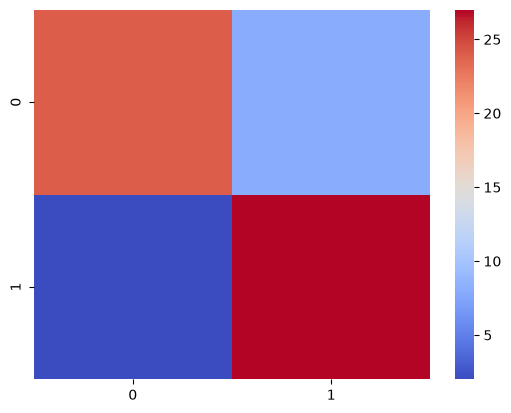

In [35]:
import seaborn as sns

sns.heatmap(confusion_matrix_rf_gs, cmap="coolwarm")